# 🧠 Redes Neurais na Prática

<h1 align="center"></h1>

<br>

---

<h2>Parte 1 — Demonstração Técnica</h2>

<blockquote>Construindo uma rede neural do zero, em Python puro, sem frameworks.</blockquote>

<h3>1.1 · Perceptron</h3>

| | |
|---|---|
| 🔹 | Estrutura de um neurônio: entradas, pesos e viés |
| 🔹 | Funções de ativação — ReLU e sigmoid |
| 🔹 | Implementação do perceptron em Python |

<h3>1.2 · Forward Pass</h3>

| | |
|---|---|
| 🔹 | Propagação do sinal pela rede camada a camada |
| 🔹 | Multiplicação matricial entre pesos e ativações |
| 🔹 | Cálculo da saída final e função de custo |

<h3>1.3 · Gradiente Descendente</h3>

| | |
|---|---|
| 🔹 | Intuição geométrica — minimizando a função de perda |
| 🔹 | Derivada parcial e taxa de aprendizado |
| 🔹 | Atualização dos pesos |

<h3>1.4 · Backpropagation</h3>

| | |
|---|---|
| 🔹 | Regra da cadeia aplicada à rede |
| 🔹 | Cálculo dos gradientes camada por camada (sentido inverso) |
| 🔹 | Acúmulo e aplicação dos gradientes e ciclo de treinamento |

---

<h2>Parte 2 — Treinando Sua Rede Neural</h2>

<blockquote>Do dataset bruto à avaliação final, construído ao vivo com PyTorch.</blockquote>

<h3>2.1 · Ferramentas Modernas</h3>

| | |
|---|---|
| 🔸 | Panorama — TensorFlow, PyTorch, Keras e JAX |
| 🔸 | Por que PyTorch para este projeto |
| 🔸 | Autodiferenciação e aceleração por GPU |

<h3>2.2 · Dataset MNIST e o Problema</h3>

| | |
|---|---|
| 🔸 | Reconhecimento de dígitos escritos à mão |
| 🔸 | 70.000 imagens 28×28 em escala de cinza |
| 🔸 | Separação treino / teste — e por que isso importa |

<h3>2.3 · Preparação dos Dados <code>🔨 ao vivo</code></h3>

| | |
|---|---|
| 🔸 | Carregamento e visualização das imagens |
| 🔸 | Normalização e reshape para entrada na rede |
| 🔸 | Criação dos DataLoaders |

<h3>2.4 · Definição da Arquitetura <code>🔨 ao vivo</code></h3>

| | |
|---|---|
| 🔸 | Classe do modelo com camadas lineares e ReLU |
| 🔸 | Escolha da função de perda — CrossEntropy |
| 🔸 | Configuração do otimizador — Adam / SGD |

<h3>2.5 · Treinamento da Rede <code>🔨 ao vivo</code></h3>

| | |
|---|---|
| 🔸 | Loop de treino: <code>forward → cost → backward → step</code> |
| 🔸 | Acompanhamento da perda por época |
| 🔸 | Salvar o modelo treinado |

<h3>2.6 · Avaliação e Predições <code>🔨 ao vivo</code></h3>

| | |
|---|---|
| 🔸 | Acurácia no conjunto de teste |
| 🔸 | Matriz de confusão |
| 🔸 | Visualização das predições corretas e dos erros |

---

<p align="center"><sub>Parte 1 · Python puro &nbsp;|&nbsp; Parte 2 · PyTorch &nbsp;|&nbsp; Dataset · MNIST</sub></p>

# Parte 1 - Demonstração Técnica


## 1.1 Perceptron

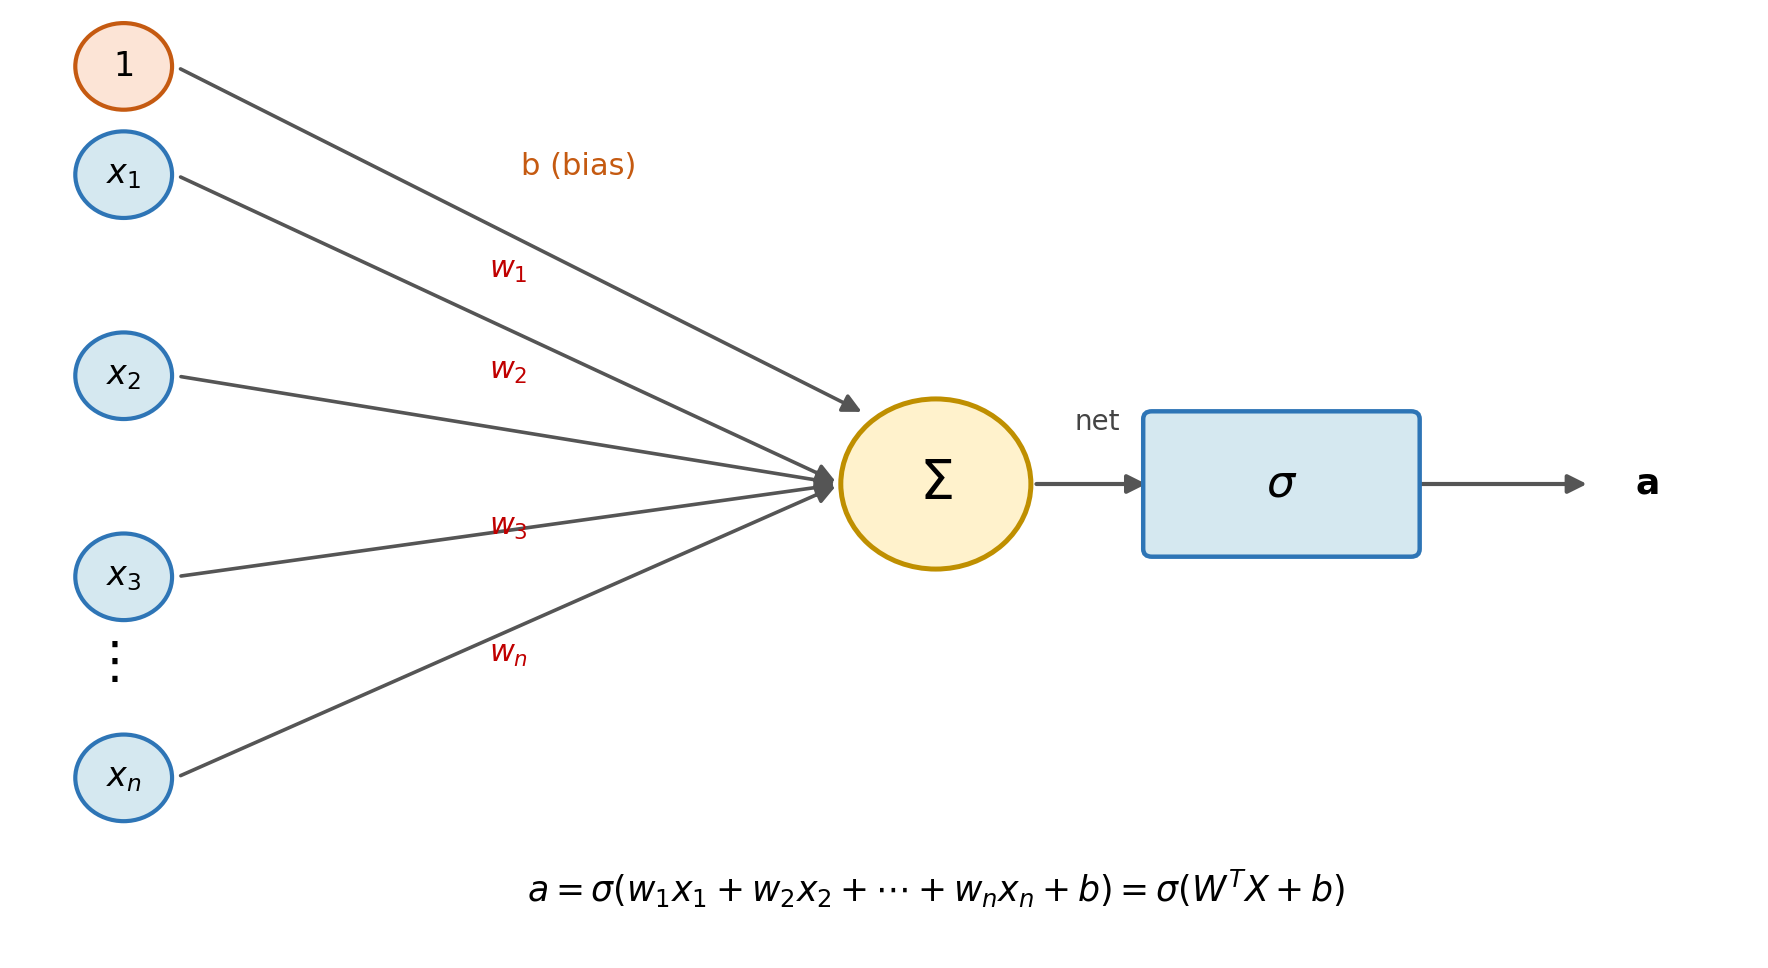


<div align="center">
<p style="font-size:1.4em">O perceptron é uma unidade computacional que recebe uma <strong>entrada</strong>, realiza uma <strong>soma ponderada</strong> com os <strong>pesos</strong> associados a cada entrada, soma o <strong>viés</strong> e passa o resultado por uma <strong>função de ativação</strong> que determina se o neurônio vai disparar ou não.</p>
</div>
<br>
<table width="100%">
<tr>
<td width="33%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.3em"><strong>Pesos</strong></p>
<p style="font-size:1.1em">Controlam a importância da entrada</p>
</td>
<td width="4%"></td>
<td width="33%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.3em"><strong>Viés</strong></p>
<p style="font-size:1.1em">Funciona como um limiar ajustável</p>
</td>
<td width="4%"></td>
<td width="33%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.3em"><strong>Função de Ativação</strong></p>
<p style="font-size:1.1em">Introduz não-linearidade</p>
</td>
</tr>
</table>

In [ ]:
import math
import random
import numpy as np
from typing import Callable

random.seed(42)

# Perceptron não otimizado - processa uma amostra por vez
def neuronio(x: list, w: list, b: float) -> float:
    z = 0
    for i in range(len(x)):
        z += x[i] * w[i]
    z += b
    return 1 / (1 + math.exp(-z)) # sigmoid

# Perceptron otimizado - processa a matriz inteira de uma vez
def perceptron(x: np.ndarray,
               w: np.ndarray,
               b: float,
               activation: Callable[[np.ndarray], np.ndarray]) -> np.ndarray:
    z = np.dot(x, w) + b
    return activation(z)

# Função de ativação sigmoid
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

# Função de ativação ReLU
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)

In [ ]:
N_SAMPLES = 10_000
N_FEATURES = 784

# Dados para o perceptron não-otimizado (listas de listas)
x_list = [[random.randint(0, 255) / 255 for _ in range(N_FEATURES)] for _ in range(N_SAMPLES)]
w_list = [random.uniform(-1, 1) for _ in range(N_FEATURES)]
b = random.uniform(-1, 1)

# Dados para o perceptron otimizado (matrizes NumPy)
x_np = np.array(x_list)
w_np = np.array(w_list)

Os dados acima simulam 10.000 amostras de 784 **features** cada - em outras palavras, são 10.000 imagens de 28x28 pixels - o perceptron não-otimizado precisa iterar sobre cada amostra individualmente, enquanto o NumPy processa a matriz de uma vez só.

In [ ]:
%%time
# Simulação com perceptron não-otimizado
saidas_list = [neuronio(x_list[i], w_list, b) for i in range(N_SAMPLES)]
print(saidas_list)

[0.3805691839249649, 0.11763503323573449, 0.01300370582926596, 0.9278215420975789, 0.021224342169121432, 0.1357747281269792, 0.9997695206385236, 0.9937158278951209, 0.57282753204593, 0.9844947044470838, 0.9814953929657992, 0.00011788101188494383, 0.29253843927262396, 0.8350282420741159, 0.9999956501588144, 0.37262694645832095, 0.9985893897879631, 0.001209864883268368, 0.5724217399628603, 0.2877499069671395, 4.1356487478936004e-05, 0.0050564425561920616, 0.00028439981383909465, 0.8889003568554399, 0.9842608022753501, 0.00042107636835818135, 0.00011078798253352284, 0.9633035360115005, 0.6285923163188291, 0.056927318076266234, 0.0037136866961773158, 0.9894690336912093, 0.9753456502443041, 0.03365617686795809, 0.055238204286515775, 0.9857449248567324, 0.9991872626307403, 0.834398770576074, 0.9969081798398318, 0.9732186061062906, 0.0017297391954775733, 0.8933563146667332, 0.11816543955314406, 0.005663510723888209, 0.4960153665842414, 0.004474601592518787, 0.3915217930280337, 0.9625394014602

In [ ]:
%%time
# Simulação com perceptron otimizado
saidas_np = perceptron(x_np, w_np, b, sigmoid)
print(saidas_np)

[0.38056918 0.11763503 0.01300371 ... 0.00234823 0.07523967 0.01353985]
CPU times: user 16 ms, sys: 0 ns, total: 16 ms
Wall time: 12.3 ms


## 1.2 Forward Pass

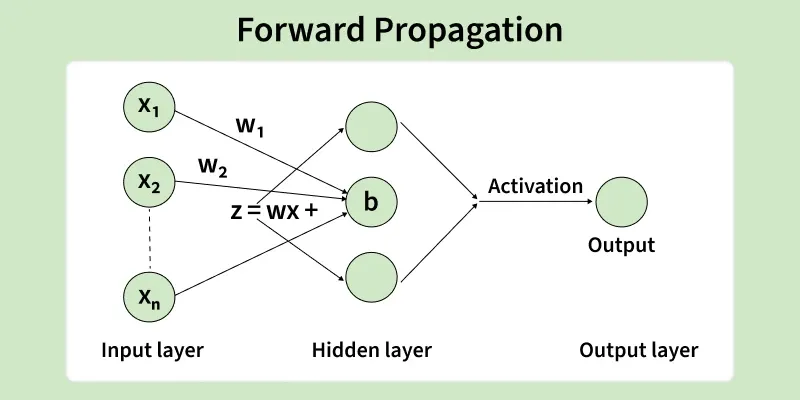

<div align="center">
<p style="font-size:1.3em">As operações dos perceptrons se empilham como funções encadeadas — a saída dos neurônios de uma camada $l$ se torna a entrada da camada $l+1$.</p>
</div>
<br>
<table width="100%">
<tr>
<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>Fully-connected Layer</strong></p>
<p style="font-size:1.1em">Cada neurônio da camada $l$ recebe como entrada a saída de <p><strong>todos</strong> os neurônios da camada anterior $l-1$, <p>cada conexão com seu próprio peso. <p>O resultado, após a função de ativação, é repassado para <strong>todos</strong> <p>os neurônios da camada seguinte $l+1$.</p>
</td>
<td width="4%"></td>
<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>Representação Matricial</strong></p>
<p style="font-size:1.1em">O estado completo de uma camada é uma multiplicação <p>de matrizes — as entradas formam <p>um vetor, os pesos formam uma matriz, e a operação</p>

$$ z = W \cdot x + b$$

<p style="font-size:1.1em">computa as pré-ativações de todos os <p>neurônios simultaneamente.</p>
</td>
</tr>
</table>

In [ ]:
# Camada de entrada L0 - Simulando 10.000 imagens 28x28 pixels (vetores (784,1))
X = np.random.randint(0, 255, (10_000, 784)) / 255  # Matriz (10_000, 784)

# Simulando Pesos e Viés de Cada Camada

# Camada oculta L1 - 128 neurônios
W1 = np.random.uniform(-1, 1, (784, 128))  # Matriz (784, 128)
b1 = np.random.uniform(-1, 1, (128,))      # Vetor  (128,)

# Camada oculta L2 - 64 neurônios
W2 = np.random.uniform(-1, 1, (128, 64))   # Matriz (128, 64)
b2 = np.random.uniform(-1, 1, (64,))       # Vetor  (64,)

# Camada de saída L3 - 10 neurônios
W3 = np.random.uniform(-1, 1, (64, 10))    # Matriz (64, 10)
b3 = np.random.uniform(-1, 1, (10,))       # Vetor  (10,)

# Simulação do Forward Pass
                                            #      W      *      X         +     b    =      z
l1 = perceptron(X,  W1, b1, relu)           # [(128, 784) @ (784, 10_000)] + (128, 1) = (128, 10_000)
l2 = perceptron(l1, W2, b2, relu)           # [(64, 128)  @ (128, 10_000)] + (64,  1) = (64,  10_000)
l3 = perceptron(l2, W3, b3, sigmoid)        # [(10, 64)   @ (64,  10_000)] + (10,  1) = (10,  10_000)

# Criando previsão
y_pred = np.argmax(l3, axis=1)  # Vetor (10_000,) — predição por amostra

# Resultado (exibe apenas a primeira amostra)
print("Saída (probabilidade por dígito) — amostra 0:")
for digito, prob in enumerate(l3[0]):
    barra = "█" * int(prob * 30)
    marcador = " ← predição" if digito == y_pred[0] else ""
    print(f"  dígito {digito}: {prob:.4f}  {barra}{marcador}")

print(f"\nPredição final: dígito {y_pred[0]}  ({l3[0][y_pred[0]]:.2%} de confiança)")

Saída (probabilidade por dígito) — amostra 0:
  dígito 0: 0.0000  
  dígito 1: 0.0000  
  dígito 2: 1.0000  █████████████████████████████
  dígito 3: 1.0000  ██████████████████████████████ ← predição
  dígito 4: 1.0000  ██████████████████████████████
  dígito 5: 1.0000  ██████████████████████████████
  dígito 6: 0.0000  
  dígito 7: 1.0000  ██████████████████████████████
  dígito 8: 1.0000  ██████████████████████████████
  dígito 9: 1.0000  ██████████████████████████████

Predição final: dígito 3  (100.00% de confiança)


<div align="center">
<h2 style="font-size:2em">Função de Custo</h2>
<p style="font-size:1.3em">Como identificar que a saída da rede não é o que queremos?</p>
</div>
<br>
<table width="100%">
<tr>
<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>O que ela mede</strong></p>
<p style="font-size:1.1em">A função de custo quantifica a <p>diferença entre a saída prevista pela <p>rede $\hat{y}$ e o valor real $y$.<br><br>Quanto maior o erro, <p>maior o custo — e é esse sinal <p>que guia o aprendizado.</p>
</td>
<td width="4%"></td>
<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>Qual vamos usar?</strong></p>
<p style="font-size:1.1em">No MNIST usamos a <p><strong>Cross-Entropy Loss</strong>, que penaliza <p>duramente predições confiantes <p>e erradas. Mas no nosso caso, para fins <p>didáticos, vamos usar <p><strong>Mean Squared Error</strong>, dada por:</p>
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

In [ ]:
def mse(y_real: np.ndarray, y_previsto: np.ndarray) -> float:
    return np.mean((y_real - y_previsto) ** 2)

# Simulando dados reais
y_real = np.eye(10)[np.random.randint(0, 10, 10_000)]  # Matriz (10_000, 10)

# Calculando o custo com base nos dados vistos
custo = mse(y_real, l3)

print(f"Custo da Rede após 1 Forward Pass: {custo:.6f}")

Custo da Rede após 1 Forward Pass: 0.506041


## 1.3 Gradiente Descendente

<div align="center">
<h2 style="font-size:2em; text-align:center"></h2>
<p style="font-size:1.3em">O algoritmo que ensina a rede a errar menos — ele ajusta os pesos na direção que reduz o custo a cada iteração.</p>
</div>

<br>

<table width="100%">
<tr>
<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>Intuição Geométrica</strong></p>
<p style="font-size:1.1em">Imagine o custo como <p>uma superfície montanhosa — o<p> objetivo é encontrar o vale mais baixo.<br><br>O gradiente aponta para a direção de <p>maior subida, então andamos no <p>sentido oposto, descendo a encosta <p>passo a passo.</p>
</td>
<td width="4%"></td>
<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>Atualização dos Pesos</strong></p>
<p style="font-size:1.1em">A cada iteração, cada peso é ajustado <p>pela regra:</p>

$$w = w - \eta \cdot \frac{\partial C}{\partial w}$$

<p style="font-size:1.1em">onde $\eta$ é a <strong>taxa de aprendizado<p></strong> — controla o tamanho do passo na descida.</p>
</td>
</tr>
</table>

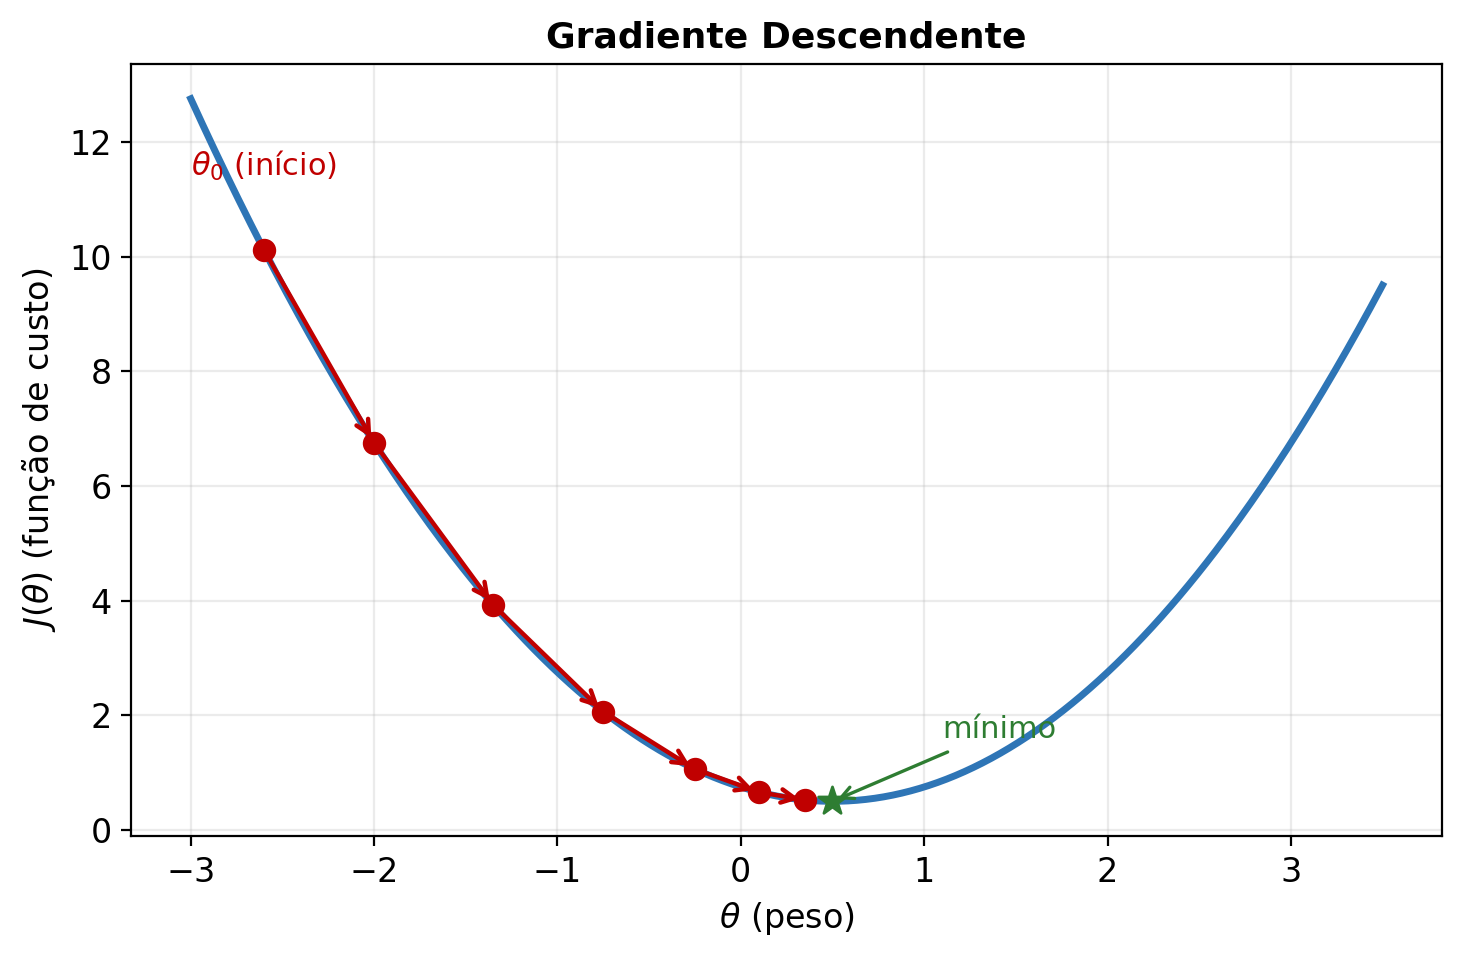

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# ── Função de custo simples: parábola ────────────────────────
custo = lambda w: (w - 3) ** 2
grad  = lambda w: 2 * (w - 3)

# ── Trajetória do gradiente descendente ──────────────────────
w, eta = -2.0, 0.2

ws, cs = [w], [custo(w)]

for _ in range(25):
    w -= eta * grad(w)
    ws.append(w)
    cs.append(custo(w))

# ── Curva de custo ───────────────────────────────────────────
w_vals = np.linspace(-3, 8, 300)
c_vals = custo(w_vals)

# ── Animação ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(w_vals, c_vals, color='steelblue', linewidth=2, label='C(w) = (w - 3)²')
ax.plot(3, 0, '*', color='gold', markersize=18, zorder=5, label='mínimo (w = 3)')
ax.set(xlabel='w', ylabel='C(w)', title='Gradiente Descendente')
ax.legend(fontsize=11)

ponto, = ax.plot([], [], 'o', color='tomato', markersize=12, zorder=6)
seta = ax.annotate('', xy=(0, 0), xytext=(0, 0))
texto = ax.text(0.02, 0.93, '', transform=ax.transAxes, fontsize=11, family='monospace')

def update(i):
    global seta

    w_i, c_i = ws[i], cs[i]
    ponto.set_data([w_i], [c_i])

    # seta mostrando a direção do próximo passo
    seta.remove()
    if i < len(ws) - 1:
        seta = ax.annotate('', xy=(ws[i+1], cs[i+1]), xytext=(w_i, c_i),
                           arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))
    else:
        seta = ax.annotate('', xy=(w_i, c_i), xytext=(w_i, c_i))

    texto.set_text(f'época: {i:2d}  |  w: {w_i:.4f}  |  C(w): {c_i:.4f}')
    return ponto, texto

ani = animation.FuncAnimation(fig, update, frames=len(ws), interval=400, blit=False)
plt.tight_layout()
plt.close()
HTML(ani.to_jshtml())

## 1.4 Backpropagation

<div align="center">
<h2 style="font-size:2em"></h2>
<p style="font-size:1.3em">Como calcular o gradiente de cada peso em uma rede com múltiplas camadas?</p>
</div>

<br>

<table width="100%">
<tr>
<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>A Ideia</strong></p>
<p style="font-size:1.1em">O erro calculado na saída precisa ser <p>distribuído para cada peso da rede — <p>o backpropagation percorre a rede no <p>sentido inverso, camada por camada, <p>atribuindo a responsabilidade de cada <p>peso no erro final.</p>
</td>
<td width="4%"></td>
<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>A Ferramenta</strong></p>
<p style="font-size:1.1em">A regra da cadeia do cálculo permite <p>decompor o gradiente do custo em <p>relação a qualquer peso:</p>

$$\frac{\partial C}{\partial w} = \frac{\partial C}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}$$

<p style="font-size:1.1em">Cada termo é simples de calcular — <p>a complexidade surge da composição.</p>
</td>
</tr>
</table>

época    0 | custo: 0.506041
época   10 | custo: 0.392937
época   20 | custo: 0.292387
época   30 | custo: 0.223554
época   40 | custo: 0.202133
época   50 | custo: 0.193331
época   60 | custo: 0.190038
época   70 | custo: 0.187542
época   80 | custo: 0.186094
época   90 | custo: 0.185081


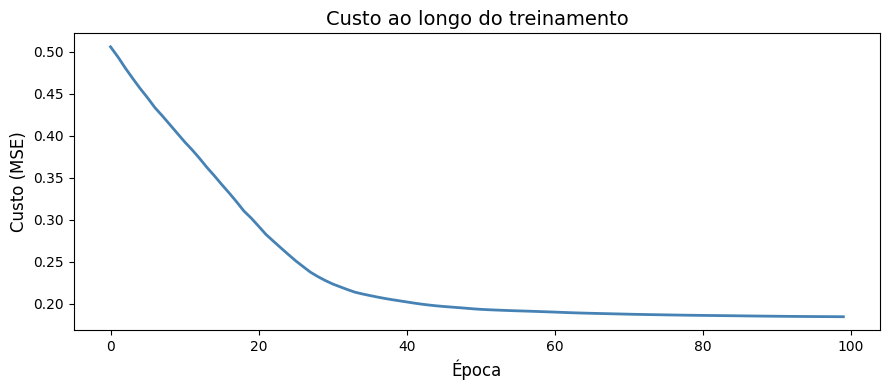

In [ ]:
# ── Forward Pass ─────────────────────────────────────────────
# Propaga o sinal da entrada até a saída, camada por camada
# Pode ser pensado como um encadeamento das funções 'perceptron' com diferentes parâmetros
def forward(X):
    l1 = perceptron(X,  W1, b1, relu)     # L0 → L1: [(10_000, 784) @ (784, 128)] + (128,) = (10_000, 128)
    l2 = perceptron(l1, W2, b2, relu)     # L1 → L2: [(10_000, 128) @ (128,  64)] + (64,) = (10_000,  64)
    l3 = perceptron(l2, W3, b3, sigmoid)  # L2 → L3: [(10_000,  64) @ (64,   10)] + (10,) = (10_000,  10)
    return l1, l2, l3

# ── Backpropagation ──────────────────────────────────────────
# Percorre a rede no sentido inverso aplicando a regra da cadeia:
#   dC/dw = dC/da · da/dz · dz/dw
# para calcular o gradiente do custo em relação a cada peso
def backward(X, y_real, l1, l2, l3, eta=0.01):
    n = X.shape[0]  # número de amostras — usado para calcular a média do gradiente

    # ── Camada de Saída L3 ───────────────────────────────────

    # Quanto a saída da rede errou em relação ao valor real?
    dC_dl3 = (2 / n) * (l3 - y_real)           # (10_000, 10)

    # A saída passou por uma sigmoid — precisamos desfazê-la
    # para descobrir o quanto z3 é responsável pelo erro
    dC_dz3 = dC_dl3 * (l3 * (1 - l3))          # (10_000, 10)

    # Sabendo a culpa de z3, distribuímos para W3 e b3
    # np.dot acumula a contribuição das 10.000 amostras de uma vez
    dW3 = np.dot(l2.T, dC_dz3)                 # (64, 10)
    db3 = np.mean(dC_dz3, axis=0)              # (10,)

    # ── Camada Oculta L2 ─────────────────────────────────────

    # l2 alimentou z3, então parte da culpa de z3 volta para l2
    # quanto maior o peso W3, mais culpa l2 recebe
    dC_dl2 = np.dot(dC_dz3, W3.T)              # (10_000, 64)

    # l2 passou por uma ReLU — onde ela zerou o valor no forward,
    # o gradiente também é zerado: aquele neurônio não participou
    dC_dz2 = dC_dl2 * (l2 > 0)                 # (10_000, 64)

    # Distribuímos a culpa de z2 para W2 e b2
    dW2 = np.dot(l1.T, dC_dz2)                 # (128, 64)
    db2 = np.mean(dC_dz2, axis=0)              # (64,)

    # ── Camada Oculta L1 ─────────────────────────────────────

    # Mesma lógica: l1 alimentou z2, então recebe parte da culpa de z2
    dC_dl1 = np.dot(dC_dz2, W2.T)              # (10_000, 128)

    # Desfaz a ReLU de l1
    dC_dz1 = dC_dl1 * (l1 > 0)                 # (10_000, 128)

    # Distribuímos a culpa de z1 para W1 e b1 — chegamos na primeira camada
    dW1 = np.dot(X.T, dC_dz1)                  # (784, 128)
    db1 = np.mean(dC_dz1, axis=0)              # (128,)

    return dW1, db1, dW2, db2, dW3, db3

# ── Atualização dos Pesos ────────────────────────────────────
# Aplica o gradiente descendente: w = w - η · dC/dw
# η (eta) é a taxa de aprendizado — controla o tamanho do passo
def atualizar(dW1, db1, dW2, db2, dW3, db3, eta=0.01):
    global W1, b1, W2, b2, W3, b3

    W1 -= eta * dW1;  b1 -= eta * db1  # atualiza L1
    W2 -= eta * dW2;  b2 -= eta * db2  # atualiza L2
    W3 -= eta * dW3;  b3 -= eta * db3  # atualiza L3

# ── Ciclo de Treinamento ─────────────────────────────────────
# A cada época: forward → custo → backward → atualizar
epochs = 100
historico_custo = []

for epoch in range(epochs):
    l1, l2, l3 = forward(X)                                         # 1. propaga o sinal
    custo = mse(y_real, l3)                                         # 2. mede o erro
    dW1, db1, dW2, db2, dW3, db3 = backward(X, y_real, l1, l2, l3)  # 3. calcula os gradientes
    atualizar(dW1, db1, dW2, db2, dW3, db3)                         # 4. atualiza os pesos

    historico_custo.append(custo)

    if epoch % 10 == 0:
        print(f"época {epoch:4d} | custo: {custo:.6f}")

# ── Gráfico do Custo ─────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(historico_custo, color='steelblue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Custo (MSE)', fontsize=12)
plt.title('Custo ao longo do treinamento', fontsize=14)
plt.tight_layout()
plt.show()

<div align="left">
<h2 style="font-size:2em"></h2>
<p style="font-size:1.3em">Legenda do Código</p>
</div>
<table style="font-size:1.15em; border-collapse:collapse; width:100%">

  <tr><td colspan="3" style="padding:12px 8px; color:#888; font-size:0.9em">── Gradiente do Custo ──────────────────────────────────────────</td></tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dC/dl3</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  (2/n) * (l3 - y_real)</td>
    <td style="padding:8px 16px; color:#aaa">derivada do MSE em relação à saída</td>
  </tr>

  <tr><td colspan="3" style="padding:12px 8px; color:#888; font-size:0.9em">── Camada de Saída L3 ──────────────────────────────────────────</td></tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dC/dz3</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  dC/dl3 * l3 * (1 - l3)</td>
    <td style="padding:8px 16px; color:#aaa">regra da cadeia com a derivada da sigmoid</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dW3</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  l2.T @ dC/dz3</td>
    <td style="padding:8px 16px; color:#aaa">derivada de z3 em relação a W3</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>db3</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  mean(dC/dz3)</td>
    <td style="padding:8px 16px; color:#aaa">derivada de z3 em relação a b3</td>
  </tr>

  <tr><td colspan="3" style="padding:12px 8px; color:#888; font-size:0.9em">── Camada Oculta L2 ────────────────────────────────────────────</td></tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dC/dl2</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  dC/dz3 @ W3.T</td>
    <td style="padding:8px 16px; color:#aaa">propagando o gradiente para L2</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dC/dz2</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  dC/dl2 * (l2 > 0)</td>
    <td style="padding:8px 16px; color:#aaa">regra da cadeia com a derivada da ReLU</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dW2</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  l1.T @ dC/dz2</td>
    <td style="padding:8px 16px; color:#aaa">derivada de z2 em relação a W2</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>db2</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  mean(dC/dz2)</td>
    <td style="padding:8px 16px; color:#aaa">derivada de z2 em relação a b2</td>
  </tr>

  <tr><td colspan="3" style="padding:12px 8px; color:#888; font-size:0.9em">── Camada Oculta L1 ────────────────────────────────────────────</td></tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dC/dl1</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  dC/dz2 @ W2.T</td>
    <td style="padding:8px 16px; color:#aaa">propagando o gradiente para L1</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dC/dz1</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  dC/dl1 * (l1 > 0)</td>
    <td style="padding:8px 16px; color:#aaa">regra da cadeia com a derivada da ReLU</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>dW1</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  X.T @ dC/dz1</td>
    <td style="padding:8px 16px; color:#aaa">derivada de z1 em relação a W1</td>
  </tr>
  <tr>
    <td style="padding:8px 16px; font-family:monospace"><strong>db1</strong></td>
    <td style="padding:8px 16px; font-family:monospace; color:#888">=  mean(dC/dz1)</td>
    <td style="padding:8px 16px; color:#aaa">derivada de z1 em relação a b1</td>
  </tr>

</table>

# Parte 2 - Treinando Sua Rede Neural


## 2.1 Ferramentas Modernas
<div align="center">
<h2 style="font-size:2em"></h2>
<p style="font-size:1.3em">Construir uma rede neural do zero é um excelente exercício — mas no dia a dia ninguém reinventa a roda. Frameworks modernos abstraem toda a matemática que vimos e adicionam aceleração por GPU, diferenciação automática e ecossistemas completos de modelos prontos.</p>
</div>

<br>

<table width="100%">
<tr>

<td width="22%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<img src="https://upload.wikimedia.org/wikipedia/commons/2/2d/Tensorflow_logo.svg" width="60px"><br><br>
<p style="font-size:1.1em"><strong>TensorFlow</strong></p>
<p style="font-size:1.0em">Google — foco <p>em produção e <p>escala industrial.</p>
</td>

<td width="4%"></td>

<td width="22%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<img src="https://upload.wikimedia.org/wikipedia/commons/1/10/PyTorch_logo_icon.svg" width="60px"><br><br>
<p style="font-size:1.1em"><strong>PyTorch</strong></p>
<p style="font-size:1.0em">Meta — preferido <p>na pesquisa, <p>flexível e intuitivo.</p>
</td>

<td width="4%"></td>

<td width="22%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<img src="https://upload.wikimedia.org/wikipedia/commons/a/ae/Keras_logo.svg" width="60px"><br><br>
<p style="font-size:1.1em"><strong>Keras</strong></p>
<p style="font-size:1.0em">API de alto nível <p>sobre TensorFlow — <p>prototipagem rápida.</p>
</td>

<td width="4%"></td>

<td width="22%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<img src="https://upload.wikimedia.org/wikipedia/commons/8/86/Google_JAX_logo.svg" width="60px"><br><br>
<p style="font-size:1.1em"><strong>JAX</strong></p>
<p style="font-size:1.0em">Google — performance <p>extrema com compilação <p>XLA.</p>
</td>

</tr>
</table>

<br>

<div align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>O que todos têm em comum: Autodiferenciação</strong></p>
<p style="font-size:1.1em">Ao invés de calcular gradientes manualmente como fizemos, esses frameworks constroem um <strong>grafo computacional</strong> durante o forward pass e calculam todos os gradientes automaticamente no backward — basta chamar <code>.backward()</code> no PyTorch ou <code>jax.grad()</code> no JAX.</p>
</div>

## 2.2 Dataset MNIST e o Problema
Antes de construir a rede, precisamos entender o que queremos resolver — reconhecer dígitos escritos à mão é um dos problemas mais clássicos da visão computacional.</p>
</div>

<br>

<table width="100%">
<tr>

<td width="22%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<img src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png" width="100px"><br><br>
<p style="font-size:1.1em"><strong>O Dataset</strong></p>
<p style="font-size:1.0em">70.000 imagens de dígitos <p>escritos à mão, divididas em <p>60.000 para treino e <p>10.000 para teste.</p>
</td>

<td width="4%"></td>

<td width="22%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<img src="mnist_exemplo.png" width="100px"><br><br>
<p style="font-size:1.1em"><strong>A Imagem</strong></p>
<p style="font-size:1.0em">Cada imagem tem <p>28×28 pixels em escala de <p>cinza — <p>valores entre 0 e 255.</p>
</td>

<td width="4%"></td>

<td width="22%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:2.5em">→</p><br>
<p style="font-size:1.1em"><strong>A Entrada da Rede</strong></p>
<p style="font-size:1.0em">28×28 é "achatado" em um <p>vetor de 784 valores e<p>normalizados entre 0 e 1.</p>
</td>

<td width="4%"></td>

<td width="22%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:2.5em">0–9</p><br>
<p style="font-size:1.1em"><strong>A Saída</strong></p>
<p style="font-size:1.0em">A rede retorna 10 <p>probabilidades — <p>uma por dígito — e o maior <p>valor é a predição.</p>
</td>

</tr>
</table>

<br>

<div align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>Por que MNIST?</strong></p>
<p style="font-size:1.1em">É simples o suficiente para treinar em minutos, mas complexo o suficiente para exigir uma rede real — por isso virou o <em>"Hello World"</em> do aprendizado profundo.</p>
</div>

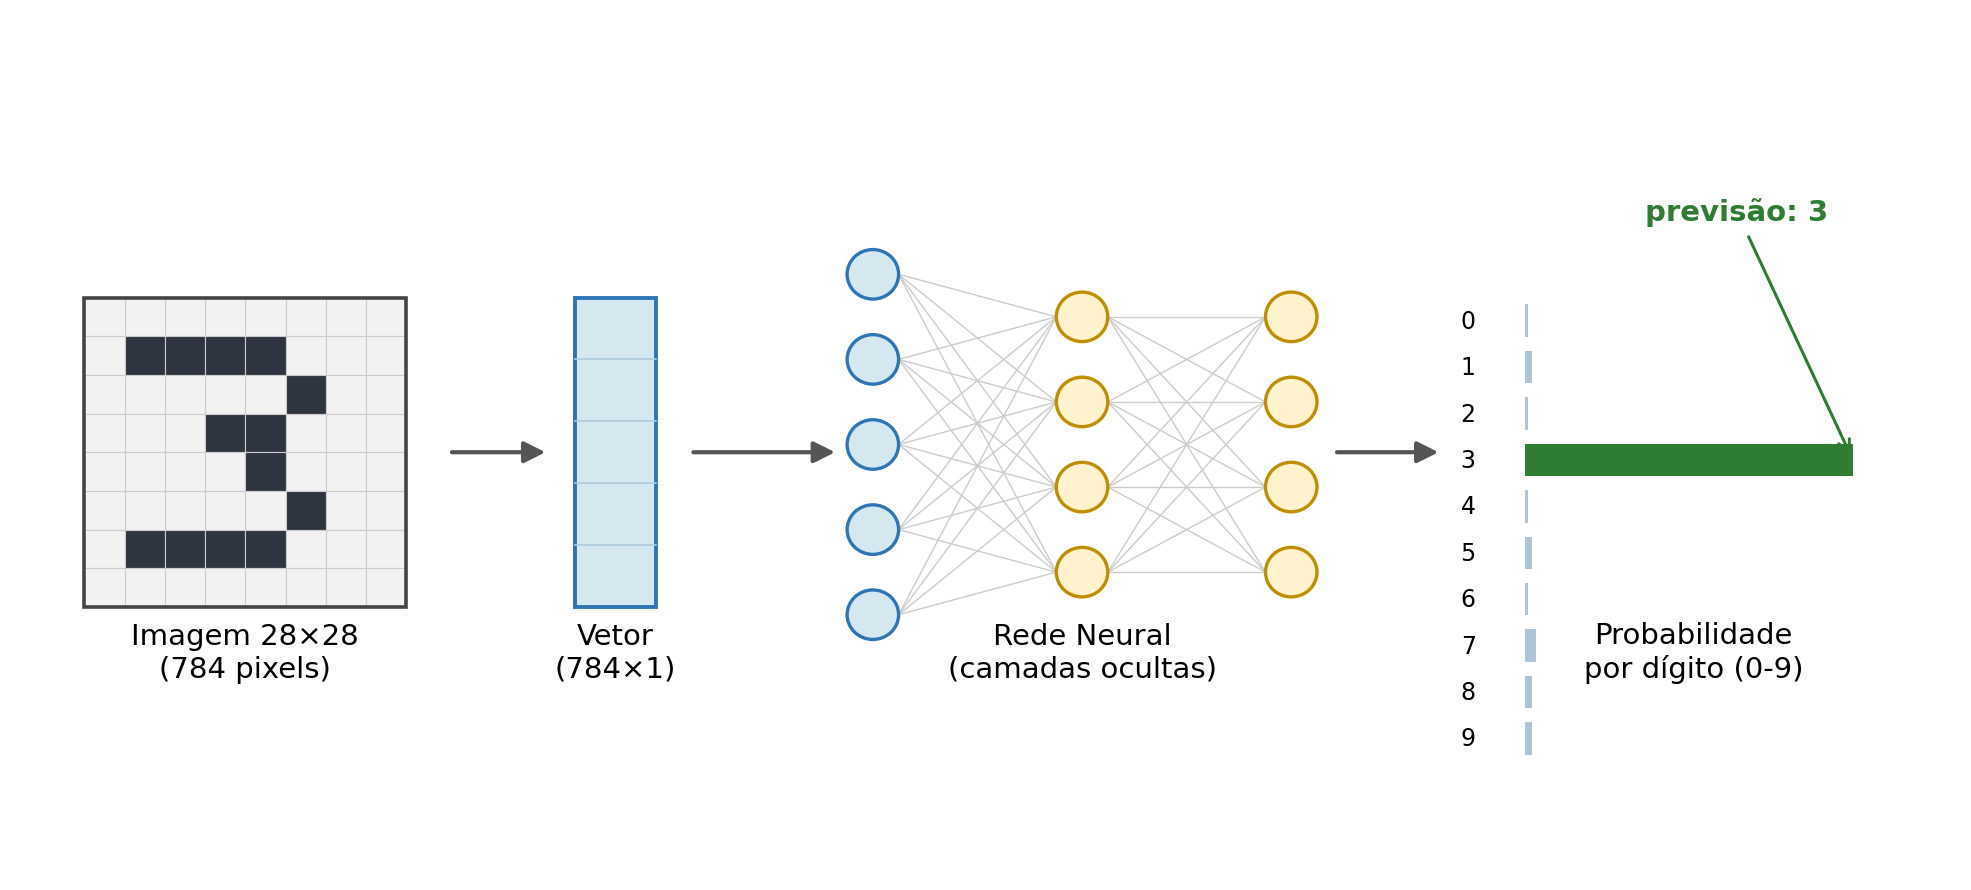

## 2.3 Preparação dos Dados

Para começar a treinar a nossa primeira **Rede Neural Artificial (RNA)** vamos primeiro carregar e preparar os nossos dados.

In [ ]:
# CÓDIGO AO VIVO

# Importando bibliotecas
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Normalização: converte pixels [0, 255] para [-1, 1]
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

> **Importando dados**

In [ ]:
# CÓDIGO AO VIVO

# Download e carregamento do dataset, já aplicando a normalização
treino = datasets.MNIST(root='data', train=True, download=True, transform=transform)
teste = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Carregando DataLoaders - funções que dividem nossos dados em mini-batches embaralhados
loader_treino = DataLoader(treino, batch_size=64, shuffle=True)
loader_teste = DataLoader(teste, batch_size=64, shuffle=False)

print()
print(f'Amostras de treino: {len(treino)}')
print(f'Amostras de teste: {len(teste)}')


Amostras de treino: 60000
Amostras de teste: 10000


> **Visualizando dados (imagens)**

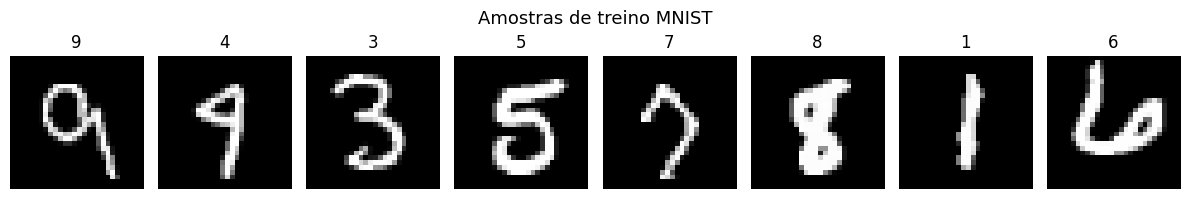

In [ ]:
import matplotlib.pyplot as plt

imgs, labels = next(iter(loader_treino))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
  ax.imshow(imgs[i].squeeze(), cmap='gray')
  ax.set_title(str(labels[i].item()))
  ax.axis('off')
plt.suptitle('Amostras de treino MNIST', fontsize=13)
plt.tight_layout()
plt.show()

## 2.4 Definição da Arquitetura
> **Definindo a arquitetura da Rede Neural**

In [ ]:
# CÓDIGO AO VIVO
import torch.nn as nn

# Estruturando nosso modelo numa classe
class RedeNeural(nn.Module):
  def __init__(self):
    super().__init__()
    self.rede = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.rede(x)

# Instanciando nosso modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = RedeNeural().to(device)

# Definindo função de custo e otimizador
criterio = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

print(modelo)
print(f'Device: {device}')

RedeNeural(
  (rede): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)
Device: cpu


## 2.5 Treinamento da Rede
> **Treinamento da Rede Neural**

In [ ]:
# CÓDIGO AO VIVO

# Ciclo de treino
epochs = 10
historico_custo = []

for epoch in range(epochs):
  modelo.train()
  custo_epoca = 0

  for imgs, labels in loader_treino:
    imgs, labels = imgs.to(device), labels.to(device)

    otimizador.zero_grad()
    saida = modelo(imgs)
    custo = criterio(saida, labels)
    custo.backward()
    otimizador.step()

    custo_epoca += custo.item()

  custo_medio = custo_epoca / len(loader_treino)
  historico_custo.append(custo_medio)
  print(f'época {epoch+1:2d}/{epochs} | custo: {custo_medio:.4f}')


# Salvando o modelo treinado (com pesos ajustados)
torch.save(modelo.state_dict(), 'modelo_mnist.pth')
print('\nModelo salvo em modelo_mnist.pth')

época  1/10 | custo: 0.5726
época  2/10 | custo: 0.3723
época  3/10 | custo: 0.3339
época  4/10 | custo: 0.3140
época  5/10 | custo: 0.2952
época  6/10 | custo: 0.2856
época  7/10 | custo: 0.2761
época  8/10 | custo: 0.2696
época  9/10 | custo: 0.2629
época 10/10 | custo: 0.2594

Modelo salvo em modelo_mnist.pth


> **Visualizando custo da Rede Neural treinada**

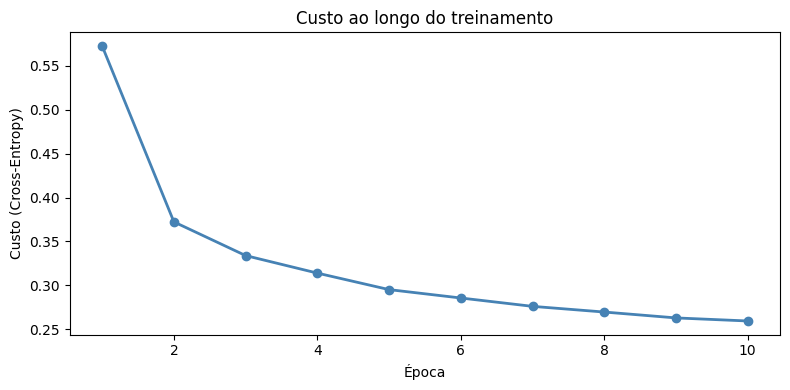

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), historico_custo, color='steelblue', linewidth=2, marker='o')
plt.xlabel('Época')
plt.ylabel('Custo (Cross-Entropy)')
plt.title('Custo ao longo do treinamento')
plt.tight_layout()
plt.show()

## 2.6 Avaliação e Predições
> **Avaliando o desempenho da Rede Neural treinada (Acurácia)**

In [ ]:
# CÓDIGO AO VIVO
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

modelo.eval()

corretos = 0
total = 0
y_real = []
y_pred = []

with torch.no_grad():
  for imgs, labels in loader_teste:
    imgs, labels = imgs.to(device), labels.to(device)
    saida = modelo(imgs)
    predicoes = torch.argmax(saida, dim=1)

    corretos += (predicoes == labels).sum().item()
    total += labels.size(0)

    y_real.extend(labels.cpu().numpy())
    y_pred.extend(predicoes.cpu().numpy())

print(f'Acurácia no conjunto de teste: {corretos / total:.2%}')


Acurácia no conjunto de teste: 91.83%


> **Avaliando o desempenho da Rede Neural treinada (Matriz de Confusão)**

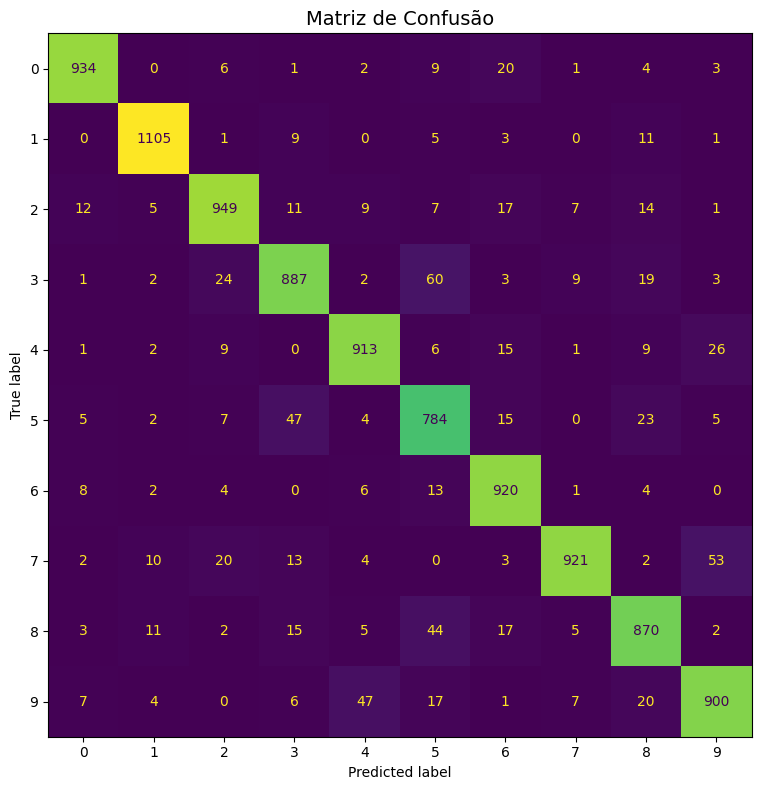

In [ ]:
# CÓDIGO AO VIVO

cm = confusion_matrix(y_real, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, colorbar=False)
plt.title('Matriz de Confusão', fontsize=14)
plt.tight_layout()
plt.show()

> **Visualizando os erros da Rede Neural**

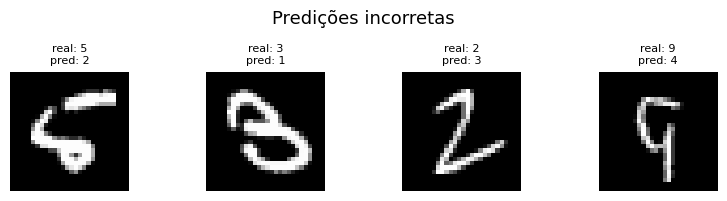

In [ ]:
imagens_teste, rotulos_teste = next(iter(loader_teste))
imagens_teste = imagens_teste.to(device)
saida         = modelo(imagens_teste)
predicoes     = torch.argmax(saida, dim=1).cpu()

erros = [i for i in range(len(predicoes)) if predicoes[i] != rotulos_teste[i]]

n     = len(erros)
ncols = min(n, 8)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
axes = np.array(axes).flat

for ax, idx in zip(axes, erros):
    ax.imshow(imagens_teste[idx].cpu().squeeze(), cmap='gray')
    ax.set_title(f'real: {rotulos_teste[idx]}\npred: {predicoes[idx]}', fontsize=8)
    ax.axis('off')

for ax in list(axes):
    if not ax.has_data():
        ax.set_visible(False)

plt.suptitle('Predições incorretas', fontsize=13)
plt.tight_layout()
plt.show()

# Conclusão
<div align="center">
<h2 style="font-size:2em"></h2>
<p style="font-size:1.3em">Partimos de um único neurônio e chegamos a uma rede capaz de reconhecer dígitos escritos à mão com uma acurácia bem alta.</p>
</div>

<br>

<table width="100%">
<tr>

<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>O que construímos</strong></p>
<p style="font-size:1.0em">Perceptron → Forward Pass → Custo → Gradiente Descendente → Backpropagation → Rede completa no MNIST</p>
</td>

<td width="4%"></td>

<td width="48%" align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>Panorama geral</strong></p>
<p style="font-size:1.0em">CNNs · RNNs · Transformers · Transfer Learning · Deploy</p>
</td>

</tr>
</table>

<br>

<div align="center" style="padding:16px; border:1px solid #ccc; border-radius:8px">
<p style="font-size:1.2em"><strong>A ideia central não muda</strong></p>
<p style="font-size:1.1em">Todo modelo de deep learning é uma composição de operações simples, ajustadas iterativamente por gradiente descendente. O resto é engenharia.</p>
</div>